In [1]:
import sys
import pandas as pd
import numpy as np

sys.path.append('../../evaluation_utils/')
from evaluation import evaluation_func as fp_eval

from collections import OrderedDict

In [2]:
color_dict = OrderedDict()

color_dict["Methods"] = OrderedDict({
    "FedProt":"black",
    "Fisher":"#D44400",
    "Stouffer":"#E69F00",
    "REM":"#2E5EAA",
    "RankProd":"#009E73"
})

# Read results

In [3]:
# read DPE results and add column sca.adj.pval with data from adj.P.Val
fedprot_data = pd.read_csv("results/DPE.csv", sep="\t")
fedprot_data["sca.adj.pval"] = fedprot_data["adj.P.Val"]
# write DPE results to file
fedprot_data.to_csv("results/DPE_results.csv", index=False, sep="\t")

In [4]:
dfs = {}

workdir = "/home/yuliya/repos/cosybio/FedProt/evaluation/ccRCC_studies/results/" 
df = fp_eval.read_results(
    workdir,
    deqms_name="central_res.tsv",
    fedprot_name="DPE_results.csv",
    fisher_name="MA_CM.tsv",
    rem_name="MA_REM.tsv",
    stouffer_name="MA_Stouffer.tsv",   
    rankprod_name="MA_RankProd.tsv"
)
dfs["ccRCC dataset"] = df
print(f"Proteins: {len(df)}")


Results loaded for DEqMS with 9605 proteins.
Results loaded for FedProt with 9605 proteins.
Results loaded for Fisher with 8520 proteins.
Results loaded for REM with 11558 proteins.
Results loaded for Stouffer with 5202 proteins.
Results loaded for RankProd with 11558 proteins.
Results loaded from /home/yuliya/repos/cosybio/FedProt/evaluation/ccRCC_studies/results/ with 5202 genes. Adj.p-values were not log-transformed.


Proteins: 5202


In [5]:
log_dfs = {}
for k in dfs:
    df = dfs[k]
    df = df.replace(0,1e-300)
    # df["pv_DEqMS"] = -np.log10(df["pv_DEqMS"])
    for m in ["DEqMS", "FedProt", "Fisher","Stouffer","REM","RankProd"]:
        df.loc[df["pv_"+m] < 1e-300, "pv_"+m] = 1e-300
        df.loc[:, "pv_"+m] = -np.log10(df["pv_"+m])
    log_dfs[k] = df

# Stats calculation

In [6]:
root_dir = "/home/yuliya/repos/cosybio/FedProt/evaluation/ccRCC_studies/"

for dataset in log_dfs:

    pval_basic_stats = fp_eval.calc_stats(
        log_dfs[dataset], 
        lfc_thr=0.58, adj_pval_thr=0.01,
        stats=["MeanDiff", "MaxDiff"],
        methods=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"],
        column_name="pv_",
        top_genes=-1
    )
    logfc_basic_stats = fp_eval.calc_stats(
        log_dfs[dataset],
        lfc_thr=0.58, adj_pval_thr=0.01,
        stats=["MeanDiff", "MaxDiff"],
        methods=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"],
        column_name="lfc_",
        top_genes=-1
    )

    pval_basic_stats.to_csv(f'{root_dir}/tables/{dataset}_pval_basic_stats.csv')
    logfc_basic_stats.to_csv(f'{root_dir}/tables/{dataset}_logfc_basic_stats.csv')

    print(f'Dataset: {dataset}')
    print("\tLogFC basic stats:")
    print(logfc_basic_stats)
    print("\tP-value basic stats:")
    print(pval_basic_stats)        

Dataset: ccRCC dataset
	LogFC basic stats:
              MeanDiff       MaxDiff
FedProt   1.084339e-15  8.437695e-15
Fisher    6.078553e-02  6.354567e-01
Stouffer  6.078553e-02  6.354567e-01
REM       6.106794e-02  5.976257e-01
RankProd  6.078553e-02  6.354567e-01
	P-value basic stats:
              MeanDiff       MaxDiff
FedProt   6.030678e-14  7.105427e-13
Fisher    9.715317e+00  1.634411e+02
Stouffer  7.184954e+00  1.184116e+02
REM       2.517359e+01  2.569017e+02
RankProd  2.889802e+01  2.862665e+02


In [7]:
# shorter version of log_dfs taking only 50% of rows randomly
short_log_dfs = {}
for dataset in log_dfs:
    short_log_dfs[dataset] = log_dfs[dataset].sample(frac=0.25, random_state=1)
    print(f"Dataset: {dataset}, proteins: {len(short_log_dfs[dataset])}")

Dataset: ccRCC dataset, proteins: 1300


Plotting correlation using p-vals - log-transformed.


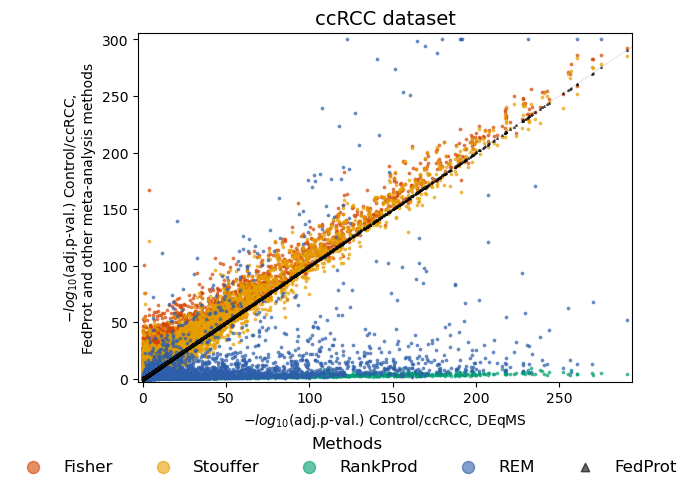

In [8]:
plot_one = fp_eval.plt_results(
    log_dfs, 
    methods=["Fisher", "Stouffer", "RankProd", "REM", "FedProt"],
    color_dict=color_dict,
    what="pv_", 
    text="", dotsize=3,
    datasets=list(log_dfs.keys()),
    figsize=(6,4.5),
    add_table=False,
    sharex=False, sharey=False,
    comparsions=["Control/ccRCC", "control/FSGS"],
    bbox_to_anchor_param=(0.5, -0.1)
)

# plt.savefig("/home/yuliya/repos/cosybio/FedDEqMS/data/04_evaluation/plots/" + "Fig3B_prototype.png", dpi=1200)

Plotting correlation using logFC values.


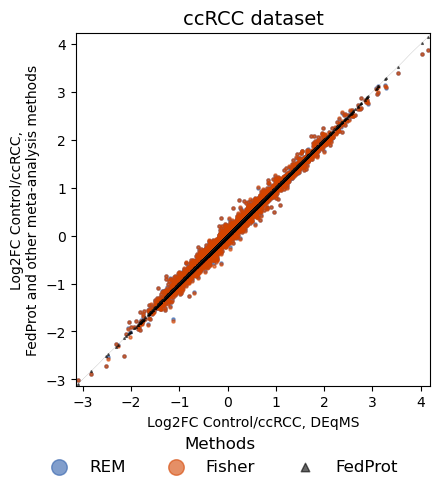

In [9]:
_ = fp_eval.plt_results(
    log_dfs, 
    methods=["REM", "Fisher", "FedProt"],
    color_dict=color_dict,
    what="lfc_", 
    text="", dotsize=5,
    figsize=(4.5,4.5),
    datasets=list(log_dfs.keys()),
    add_table=False,
    sharex =False, sharey=False,
    comparsions=["Control/ccRCC", "control/FSGS"],
    # set_lims = [[-2,2], [-0.8, 0.8]],
    bbox_to_anchor_param=(0.5, -0.1)
)

# plt.savefig("/home/yuliya/repos/cosybio/FedDEqMS/data/04_evaluation/plots/" + "Fig3B_prototype.png", dpi=1200)

# Top lists

In [10]:
fp_fn_b = fp_eval.calc_stats(
    log_dfs["ccRCC dataset"],
    lfc_thr=0.5, adj_pval_thr=0.05,
    stats=["FP", "FN", "Jaccard"],
    methods=["FedProt", "Fisher", "Stouffer", "REM", "RankProd"],
    column_name="pv_",
    top_genes=-1
)
fp_fn_b.to_csv(f'{root_dir}/tables/Bacterial_FP_FN.csv')
# for Jaccard column, round to 3 decimal places
fp_fn_b["Jaccard"] = fp_fn_b["Jaccard"].round(2)

print("\tFP/FN bacterial dataset:")
print(fp_fn_b)  

	FP/FN bacterial dataset:
             FP     FN  Jaccard
FedProt     0.0    0.0     1.00
Fisher    137.0  153.0     0.86
Stouffer  137.0  153.0     0.86
REM        51.0  391.0     0.78
RankProd   13.0  462.0     0.75


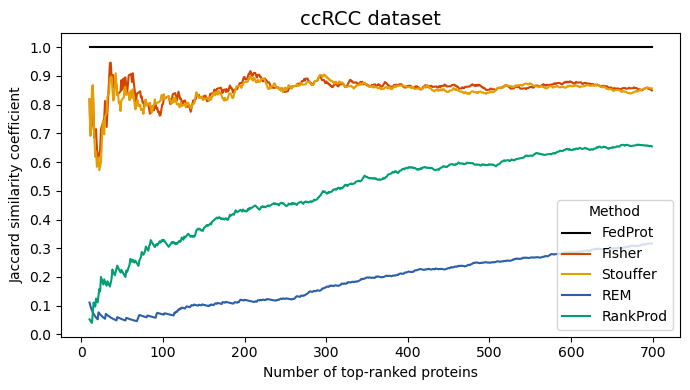

In [11]:
min_n_genes = 10
step = 1

_, _ = fp_eval.plot_stats_for_topN(
    log_dfs,
    datasets = list(log_dfs.keys()),
    methods=["FedProt", "Fisher","Stouffer","REM", "RankProd"],
    metrics=["Jaccard"],
    min_n_genes=min_n_genes,
    max_n_genes=[700, 300],
    figsize=(7,4),
    step=step,
    color_dict=color_dict,
    sharey=False,
    )